# Calculating diversity and mutation

## Calculating mutational load
To calculate mutational load, the functions from `immcantation` suite's `shazam` [[Gupta2015]](https://academic.oup.com/bioinformatics/article/31/20/3356/195677) can be accessed via `rpy2` to work with the `dandelion` class object.

This can be run immediately after `pp.reassign_alleles` during the reannotation pre-processing stage because the required germline columns should be present in the genotyped `.tsv` file. I would recommend to run this after TIgGER [[Gadala-Maria2015]](https://www.pnas.org/content/112/8/E862), after the v_calls were corrected. Otherwise, if the reannotation was skipped, you can run it now as follows:

<b>Import modules</b>

In [1]:
import os
import dandelion as ddl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scanpy as sc

sc.settings.verbosity = 3

# change to tutorials directory
os.chdir("dandelion_tutorial")

<b>Read in the previously saved files</b>

In [2]:
adata = sc.read_h5ad("adata.h5ad")
adata

AnnData object with n_obs × n_vars = 23702 × 1402
    obs: 'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'gmm_pct_count_clusters_keep', 'scrublet_score', 'is_doublet', 'filter_rna', 'has_contig', 'locus_VDJ', 'locus_VJ', 'productive_VDJ', 'productive_VJ', 'v_call_VDJ', 'd_call_VDJ', 'j_call_VDJ', 'v_call_VJ', 'j_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'junction_VDJ', 'junction_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'v_call_B_VDJ', 'd_call_B_VDJ', 'j_call_B_VDJ', 'v_call_B_VJ', 'j_call_B_VJ', 'c_call_B_VDJ', 'c_call_B_VJ', 'productive_B_VDJ', 'productive_B_VJ', 'umi_count_B_VDJ', 'umi_count_B_VJ', 'v_call_VDJ_main', 'v_call_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'v_call_B_VDJ_main', 'd_call_B_VDJ_main', 'j_call_B_VDJ_main', 'v_call_B_VJ_main', 'j_call_B_VJ_main', 'isotype', 'isotype_status', 'locus_status', 'chain_status', 'rearrangement_status_VDJ', 'rearrangement_status_V

<div class="alert alert-info">

Note
    
This tutorial will be trying to quantify mutations in the BCR data, and this function requires access to IMGT-formatted VDJ gene calls with allelic information. So if you have ran `vdj.simplify` before this tutorial, then it would not work. Therefore, we are loading in the `Dandelion` object without simplified calls.

</div>

In [3]:
vdj = ddl.read_h5ddl("dandelion_results.h5ddl")
vdj

Dandelion class object with n_obs = 2111 and n_contigs = 7355
    data: 'sequence_id', 'sequence', 'rev_comp', 'productive', 'v_call', 'd_call', 'j_call', 'sequence_alignment', 'germline_alignment', 'junction', 'junction_aa', 'v_cigar', 'd_cigar', 'j_cigar', 'stop_codon', 'vj_in_frame', 'locus', 'c_call', 'junction_length', 'np1_length', 'np2_length', 'v_sequence_start', 'v_sequence_end', 'v_germline_start', 'v_germline_end', 'd_sequence_start', 'd_sequence_end', 'd_germline_start', 'd_germline_end', 'j_sequence_start', 'j_sequence_end', 'j_germline_start', 'j_germline_end', 'v_score', 'v_identity', 'v_support', 'd_score', 'd_identity', 'd_support', 'j_score', 'j_identity', 'j_support', 'fwr1', 'fwr2', 'fwr3', 'fwr4', 'cdr1', 'cdr2', 'cdr3', 'cell_id', 'consensus_count', 'umi_count', 'v_call_10x', 'd_call_10x', 'j_call_10x', 'junction_10x', 'junction_10x_aa', 'j_support_igblastn', 'j_score_igblastn', 'j_call_igblastn', 'j_call_blastn', 'j_identity_blastn', 'j_alignment_length_blastn', 

In [4]:
# let's rerun the find_clone step again as it didn't get copied over
ddl.tl.find_clones(vdj)

Finding clonotypes


Finding clones based on B cell VDJ chains using junction_aa: 100%|██████████| 247/247 [00:00<00:00, 5105.00it/s]
Finding clones based on B cell VJ chains using junction_aa: 100%|██████████| 209/209 [00:00<00:00, 5795.77it/s]
Refining clone assignment based on VJ chain pairing : 100%|██████████| 2236/2236 [00:00<00:00, 625982.09it/s]


Initialising Dandelion object
 finished: Updated Dandelion object: 
   'data', contig-indexed AIRR table
   'metadata', cell-indexed observations table
 (0:00:01)


In [5]:
# let's recreate the vdj object with only the first two samples
subset_data = vdj.data[
    vdj.data["sample_id"].isin(["sc5p_v2_hs_PBMC_1k", "sc5p_v2_hs_PBMC_10k"])
]
subset_data

,sequence_id,sequence,rev_comp,productive,v_call,d_call,j_call,sequence_alignment,germline_alignment,junction,...,j_call_multimappers,j_call_multiplicity,j_call_sequence_start_multimappers,j_call_sequence_end_multimappers,j_call_support_multimappers,mu_count,ambiguous,extra,rearrangement_status,clone_id
sequence_id,,,,,,,,,,,,,,,,,,,,,


In [6]:
# create a new Dandelion class with this subset
vdj2 = ddl.Dandelion(subset_data)
vdj2

/Users/uqztuong/Documents/GitHub/dandelion/src/dandelion/utilities/_core.py:358: UserWarning: 
Dandelion expects .data.index to contain strings, but got values like:
    []
    Inferred to be: empty



ValueError: No objects to concatenate

### `store_germline_reference`

We can store the corrected germline fasta files (after running TIgGER) in the `Dandelion` class as a dictionary.

In [ ]:
# update the germline using the corrected files after tigger
vdj2.store_germline_reference(
    corrected="tutorial_scgp1/tutorial_scgp1_heavy_igblast_db-pass_genotype.fasta",
    germline=None,
    org="human",
)

Updating germline reference
 finished: Updated Dandelion object: 
   'germline', updated germline reference
 (0:00:00)


### `pp.create_germlines`

Then we run `pp.create_germline` to (re)create the `germline_alignment_d_mask` column in the data. This works by calling `CreateGermlines.py` with only `-d` and `-r` options. Add further arguments with `additional_args` like below for your needs. See https://changeo.readthedocs.io/en/stable/examples/germlines.html for more info.

<div class="alert alert-info">

Note
    
In order for this function to work, the V/D/J calls need to be in IMGT format with allelic information. So if you have ran `vdj.simplify` before this step, then it would not work.

</div>
    

In [ ]:
ddl.pp.create_germlines(vdj2, additional_args=["--vf", "v_call_genotyped"])

Reconstructing germline sequences
Running command: CreateGermlines.py -d /var/folders/_r/j_8_fj3x28n2th3ch0ckn9c40000gt/T/tmpnibqulmo/tmp.tsv -r /var/folders/_r/j_8_fj3x28n2th3ch0ckn9c40000gt/T/tmpnibqulmo/germ.fasta --vf v_call_genotyped

     START> CreateGermlines
      FILE> tmp.tsv
GERM_TYPES> dmask
 SEQ_FIELD> sequence_alignment
   V_FIELD> v_call_genotyped
   D_FIELD> d_call
   J_FIELD> j_call
    CLONED> False

PROGRESS> 11:36:45 |####################| 100% (183) 0.0 min

 OUTPUT> tmp_germ-pass.tsv
RECORDS> 183
   PASS> 183
   FAIL> 0
    END> CreateGermlines

 finished: Returning Dandelion object: 
 (0:00:01)


Dandelion class object with n_obs = 73 and n_contigs = 183
    data: 'sequence_id', 'sequence', 'rev_comp', 'productive', 'v_call', 'd_call', 'j_call', 'sequence_alignment', 'germline_alignment', 'junction', 'junction_aa', 'v_cigar', 'd_cigar', 'j_cigar', 'stop_codon', 'vj_in_frame', 'locus', 'c_call', 'junction_length', 'np1_length', 'np2_length', 'v_sequence_start', 'v_sequence_end', 'v_germline_start', 'v_germline_end', 'd_sequence_start', 'd_sequence_end', 'd_germline_start', 'd_germline_end', 'j_sequence_start', 'j_sequence_end', 'j_germline_start', 'j_germline_end', 'v_score', 'v_identity', 'v_support', 'd_score', 'd_identity', 'd_support', 'j_score', 'j_identity', 'j_support', 'fwr1', 'fwr2', 'fwr3', 'fwr4', 'cdr1', 'cdr2', 'cdr3', 'cell_id', 'consensus_count', 'umi_count', 'c_sequence_alignment', 'c_germline_alignment', 'c_sequence_start', 'c_sequence_end', 'c_score', 'c_identity', 'junction_aa_length', 'fwr1_aa', 'fwr2_aa', 'fwr3_aa', 'fwr4_aa', 'cdr1_aa', 'cdr2_aa', 'cdr3_aa'

Ensure that the `germline_alignment_d_mask` column is populated or subsequent steps will fail.

In [ ]:
vdj2.data[["v_call_genotyped", "germline_alignment_d_mask"]]

,v_call_genotyped,germline_alignment_d_mask
sequence_id,,
sc5p_v2_hs_PBMC_1k_AACTCCCAGGCTAGGT_contig_1,IGLV5-45*03,CAGGCTGTGCTGACTCAGCCGTCTTCC...CTCTCTGCATCTCCTG...
sc5p_v2_hs_PBMC_1k_AACTCCCAGGCTAGGT_contig_2,IGHV4-61*02,CAGGTGCAGCTGCAGGAGTCGGGCCCA...GGACTGGTGAAGCCTT...
sc5p_v2_hs_PBMC_1k_AACTCCCAGGCTAGGT_contig_3,IGLV2-5*01,CAGTCTGCCCTGATTCAGCCTCCCTCC...GTGTCCGGGTCTCCTG...
sc5p_v2_hs_PBMC_1k_AACTCTTGTCATCGGC_contig_2,IGHV3-21*01,GAGGTGCAGCTGGTGGAGTCTGGGGGA...GGCCTGGTCAAGCCTG...
sc5p_v2_hs_PBMC_1k_AACTCTTGTCATCGGC_contig_1,IGLV4-69*01,CAGCTTGTGCTGACTCAATCGCCCTCT...GCCTCTGCCTCCCTGG...
...,...,...
sc5p_v2_hs_PBMC_1k_TTCCCAGAGTACATGA_contig_2,"IGHV3-23*01,IGHV3-23D*01",GAGGTGCAGCTGTTGGAGTCTGGGGGA...GGCTTGGTACAGCCTG...
sc5p_v2_hs_PBMC_1k_TTGAACGCAGGCTGAA_contig_1,IGKV1-8*01,GCCATCCGGATGACCCAGTCTCCATCCTCATTCTCTGCATCTACAG...
sc5p_v2_hs_PBMC_1k_TTGAACGCAGGCTGAA_contig_2,IGHV3-30-3*01,CAGGTGCAGCTGGTGGAGTCTGGGGGA...GGCGTGGTCCAGCCTG...


The default behaviour is to mask the D region with Ns with option.

### `pp.quantify_mutations`

The options for `pp.quantify_mutations` are the same as the basic mutational load analysis [vignette](https://shazam.readthedocs.io/en/version-0.1.8---mutation-profiling-enhancements/vignettes/Mutation-Vignette/) [[Gupta2015]](https://academic.oup.com/bioinformatics/article/31/20/3356/195677). The default behavior is to sum all mutations scores (heavy and light chains, silent and replacement mutations) for the same cell.

Again, this function can be run immediately after `pp.reassign_alleles` on the genotyped `.tsv` files (without loading into `pandas` or `Dandelion`). Here I'm illustrating a few other options that may be useful.

In [ ]:
# switching back to using the full vdj object
ddl.pp.quantify_mutations(vdj)

Quantifying mutations
 finished: Updated Dandelion object: 
   'data', contig-indexed AIRR table
   'metadata', cell-indexed observations table
 (0:00:11)


In [ ]:
ddl.pp.quantify_mutations(vdj, combine=False)

Quantifying mutations
 finished: Updated Dandelion object: 
   'data', contig-indexed AIRR table
   'metadata', cell-indexed observations table
 (0:00:05)


Specifying `split_locus = True` will split up the results for the different chains.

In [ ]:
ddl.pp.quantify_mutations(vdj, split_locus=True)

Quantifying mutations
 finished: Updated Dandelion object: 
   'data', contig-indexed AIRR table
   'metadata', cell-indexed observations table
 (0:00:05)


To update the `AnnData` object, simply rerun `tl.transfer`.

In [ ]:
ddl.tl.transfer(adata, vdj)

Transferring network
 finished: updated `.obs` with `.metadata`
wrote `.obsm['X_vdj']` and `.obsm['X_vdj_expanded']`
wrote adata.obsp['connectivities'] & ['distances'] from graph[0]
stored RNA matrices under rna_* keys (stashed)
stored vdj matrices under 'vdj_connectivities' (+ '_expanded' and + '_full' if available)
added `.uns['clone_id']` clone-level mapping (0:00:00)


In [ ]:
adata

AnnData object with n_obs × n_vars = 23643 × 1423
    obs: 'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'gmm_pct_count_clusters_keep', 'scrublet_score', 'is_doublet', 'filter_rna', 'has_contig', 'locus_VDJ', 'locus_VJ', 'productive_VDJ', 'productive_VJ', 'v_call_VDJ', 'd_call_VDJ', 'j_call_VDJ', 'v_call_VJ', 'j_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'junction_VDJ', 'junction_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'v_call_B_VDJ', 'd_call_B_VDJ', 'j_call_B_VDJ', 'v_call_B_VJ', 'j_call_B_VJ', 'c_call_B_VDJ', 'c_call_B_VJ', 'productive_B_VDJ', 'productive_B_VJ', 'umi_count_B_VDJ', 'umi_count_B_VJ', 'v_call_VDJ_main', 'v_call_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'v_call_B_VDJ_main', 'd_call_B_VDJ_main', 'j_call_B_VDJ_main', 'v_call_B_VJ_main', 'j_call_B_VJ_main', 'isotype', 'isotype_status', 'locus_status', 'chain_status', 'rearrangement_status_VDJ', 'rearrangement_status_V

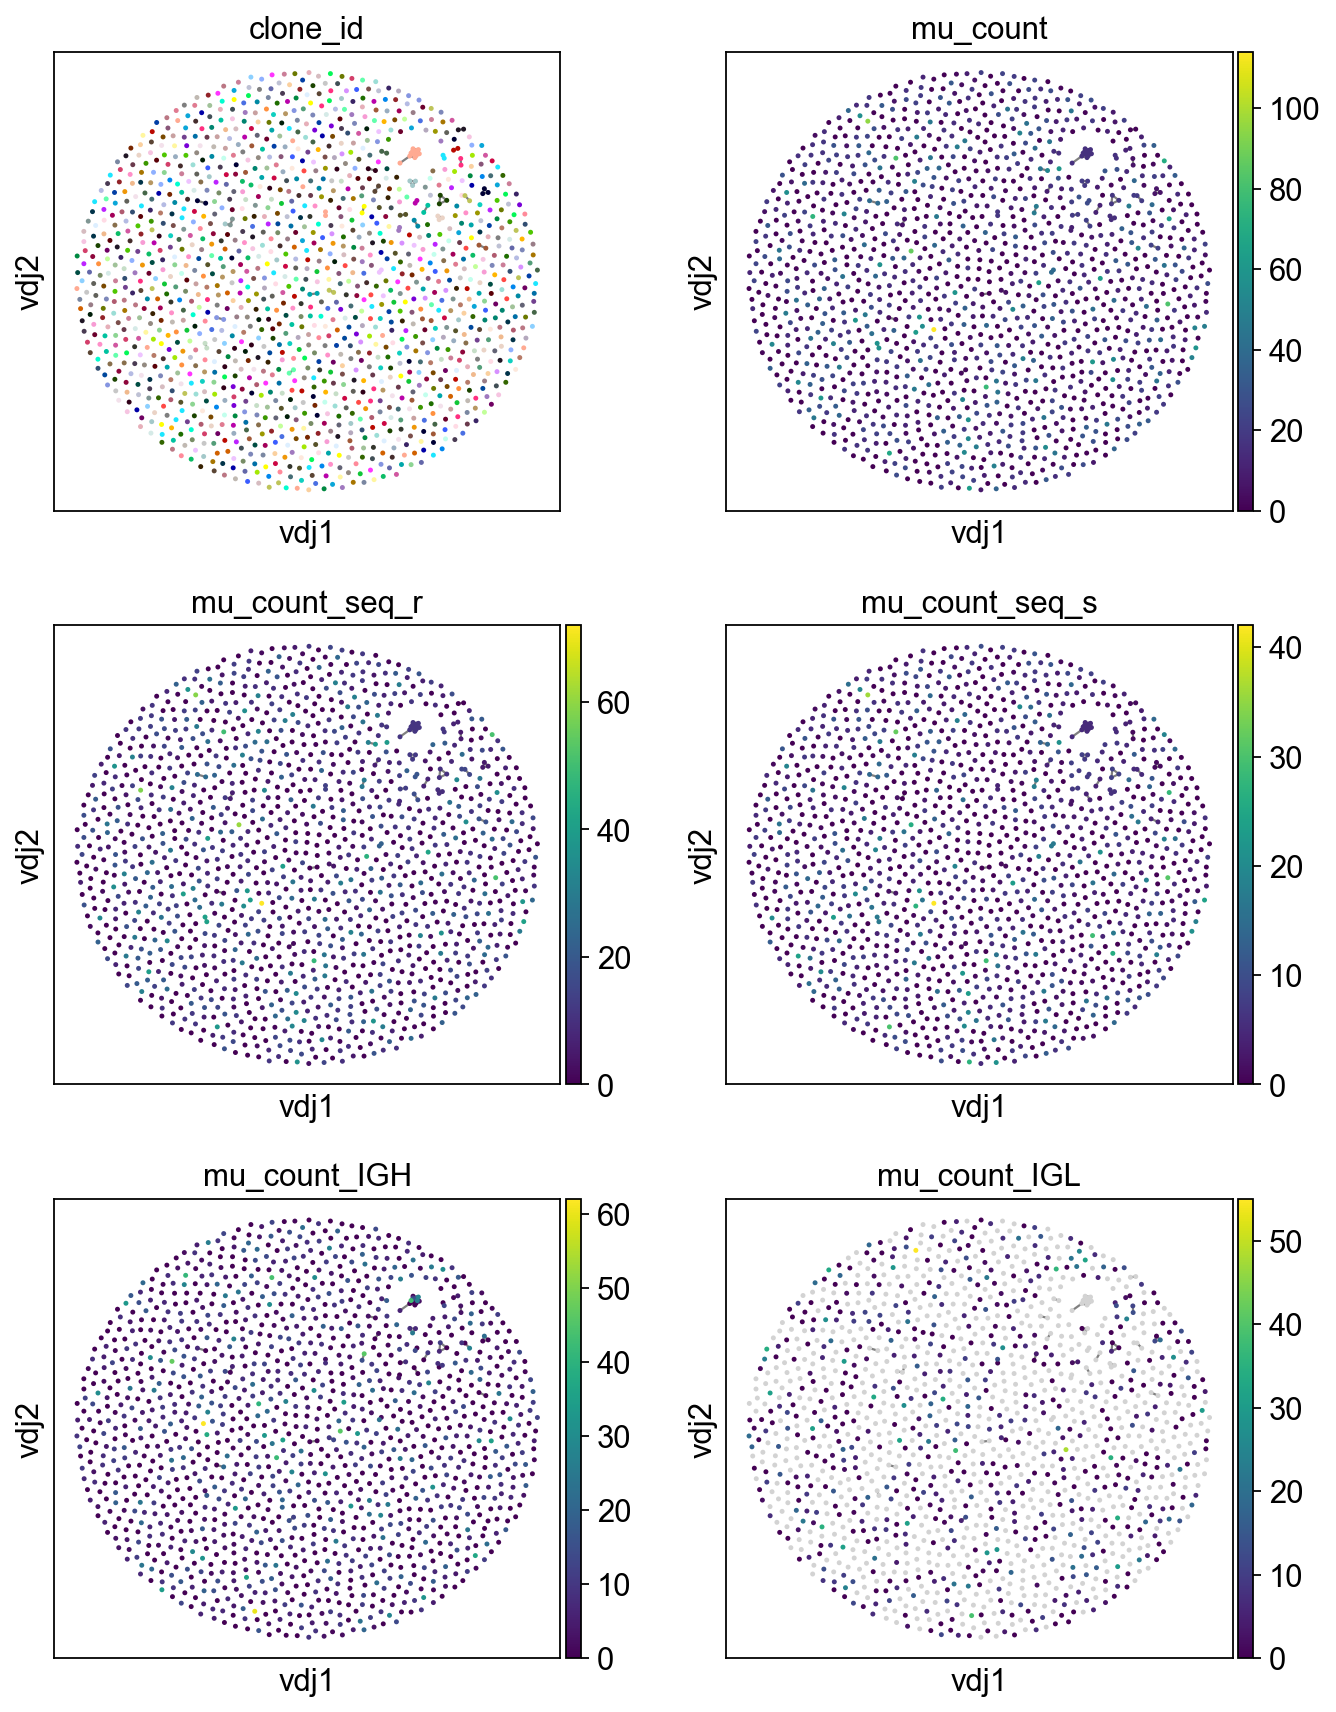

In [ ]:
from scanpy.plotting.palettes import default_28, default_102

sc.set_figure_params(figsize=[4, 4])
ddl.pl.clone_network(
    adata,
    color=[
        "clone_id",
        "mu_count",
        "mu_count_seq_r",
        "mu_count_seq_s",
        "mu_count_IGH",
        "mu_count_IGL",
    ],
    ncols=2,
    legend_loc="none",
    legend_fontoutline=3,
    edges_width=1,
    palette=default_28 + default_102,
    color_map="viridis",
    size=20,
)

## Calculating diversity

`ddl.tl.clone_rarefaction`

We can use `ddl.tl.clone_rarefaction` to generate rarefaction curves for the clones. Here, I am grouping by `sampleid` in the `AnnData` object. The function will work on both `AnnData` and `Dandelion` objects. We fit the rarefaction curves using a Michaelis–Menten model and extrapolate them beyond the observed data points, with the asymptote providing an estimate of the expected number of unique clones at larger sample sizes.

Calculating rarefaction + extrapolation: 100%|██████████| 3/3 [00:00<00:00, 13.11it/s]


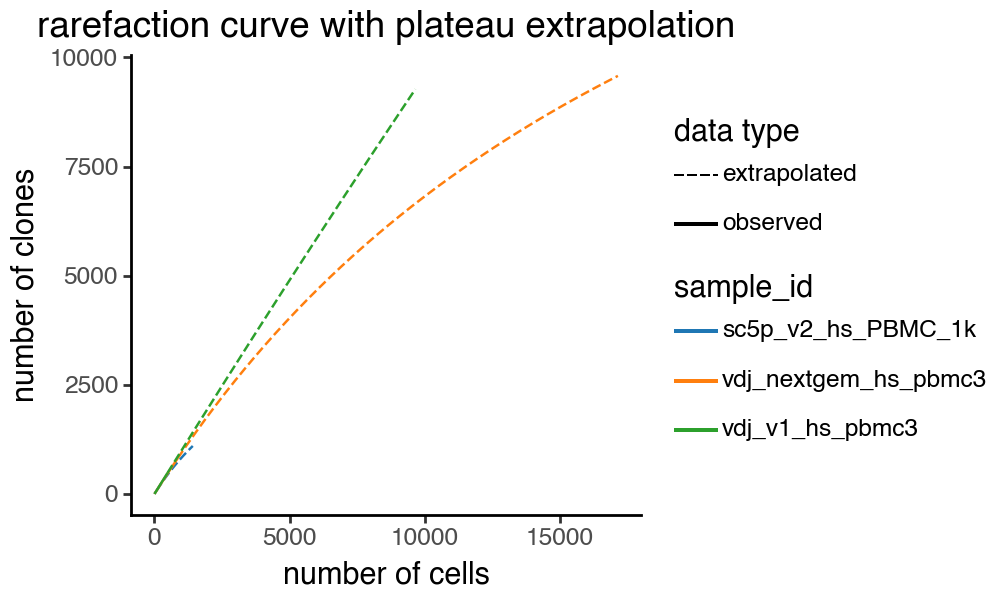

In [ ]:
ddl.tl.clone_rarefaction(adata, groupby="sample_id", plot=True)

You can also use it to return the results without plotting:

In [ ]:
pred = ddl.tl.clone_rarefaction(adata, groupby="sample_id", plot=False)
pred

Calculating rarefaction + extrapolation: 100%|██████████| 3/3 [00:00<00:00, 13.41it/s]


,cells,yhat,group,type,plateau
0,1,0.985657,vdj_nextgem_hs_pbmc3,observed,20977.711473
1,2,1.971227,vdj_nextgem_hs_pbmc3,observed,20977.711473
2,3,2.956708,vdj_nextgem_hs_pbmc3,observed,20977.711473
3,4,3.942102,vdj_nextgem_hs_pbmc3,observed,20977.711473
4,5,4.927408,vdj_nextgem_hs_pbmc3,observed,20977.711473
...,...,...,...,...,...
28232,1415,1096.798517,sc5p_v2_hs_PBMC_1k,extrapolated,4628.762094
28233,1416,1097.399060,sc5p_v2_hs_PBMC_1k,extrapolated,4628.762094
28234,1417,1097.999412,sc5p_v2_hs_PBMC_1k,extrapolated,4628.762094
28235,1418,1098.599573,sc5p_v2_hs_PBMC_1k,extrapolated,4628.762094


Let's try and resample the data to a larger number of cells to see how many unique clones we would expect to see if we simulated to have more data.

Resampling to 5000 cells.
The AIRR data needs to undergo sanitization, apologies for any delays...
Finding clonotypes


Finding clones based on B cell VDJ chains using junction_aa: 100%|██████████| 191/191 [00:00<00:00, 7308.22it/s]
Finding clones based on B cell VJ chains using junction_aa: 100%|██████████| 184/184 [00:00<00:00, 7916.05it/s]
Refining clone assignment based on VJ chain pairing : 100%|██████████| 5000/5000 [00:00<00:00, 618665.41it/s]


Initialising Dandelion object
 finished: Updated Dandelion object: 
   'data', contig-indexed AIRR table
   'metadata', cell-indexed observations table
 (0:00:02)


Calculating rarefaction + extrapolation: 100%|██████████| 3/3 [00:00<00:00,  3.79it/s]


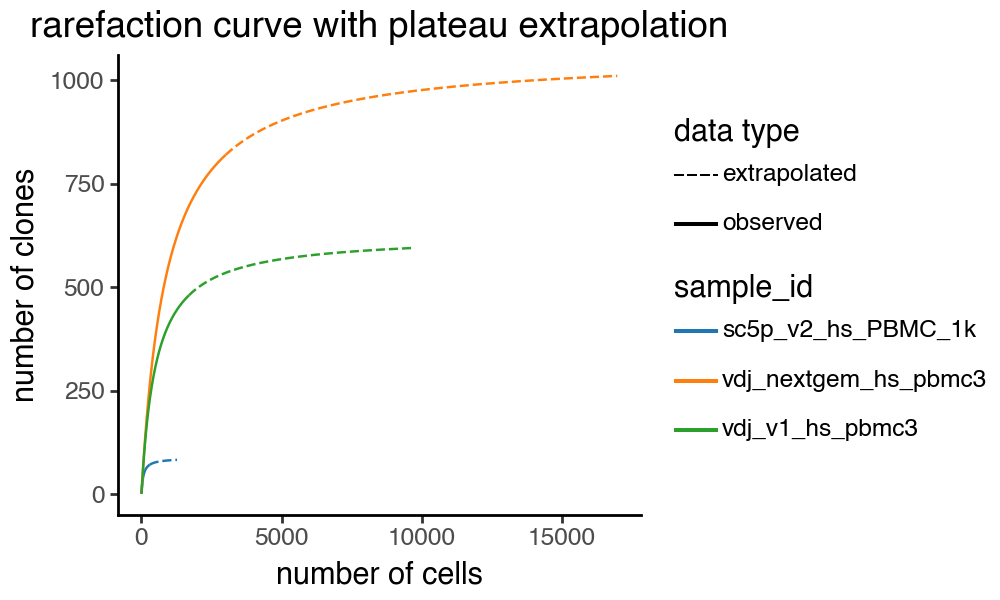

In [ ]:
vdj_large = ddl.tl.vdj_sample(vdj_data=vdj, size=5000)
# re-run clone finding on the larger dataset
ddl.tl.find_clones(vdj_large)
ddl.tl.clone_rarefaction(
    vdj_large,
    groupby="sample_id",
    plot=True,
    palette=adata.uns["sample_id_colors"],
)

### `ddl.tl.clone_diversity`

`ddl.tl.clone_diversity` allows for calculation of diversity measures such as <b>Chao1</b>, <b>Shannon Entropy</b> and <b>Gini indices</b>. 

For Gini indices, we provide several types of measures, inspired by bulk BCRseq analysis methods from [[Bashford-Rogers2013]](https://genome.cshlp.org/content/23/11/1874):

The following two indices are returned with `network_metric="clone_network"`.
   
   <b>I. network cluster/clone size Gini index</b> 
    
   In a contracted BCR network (where identical BCRs are collapsed into the same node/vertex), disparity in the distribution should be correlated to the amount of mutation events i.e. larger networks should indicate more mutation events and smaller networks should indicate lesser mutation events.

   <b>II. network vertex/node size Gini index</b>
    
   In the same contracted network, we can count the number of merged/contracted nodes; nodes with higher count numbers indicate more clonal expansion. Thus, disparity in the distribution of count numbers (referred to as vertex size) should be correlated to the overall clonality i.e. clones with larger vertex sizes are more monoclonal and clones with smaller vertex sizes are more polyclonal.
    
Therefore, a Gini index of 1 on either measures repesents perfect inequality (i.e. monoclonal and highly mutated) and a value of 0 represents perfect equality (i.e. polyclonal and unmutated).

<div class="alert alert-warning">

Note

However, there are a few limitations/challenges that comes with single-cell data: 

- <b>A.</b> In the process of contracting the network, we discard the single-cell level information. <br><br>

- <b>B.</b> Contraction of network is very slow, particularly when there is a lot of clonally-related cells. <br><br>

- <b>C.</b> For the full implementation and interpretation of both measures, although more evident with cluster/clone size, it requires the BCR repertoire to be reasonably/deeply sampled and we know that this is currently limited by the low recovery from single cell data with current technologies.

</div>

Therefore, we implement a few work around options, and 'experimental' options below, to try and circumvent these issues.

Firstly, as a work around for (C), the cluster size gini index can be calculated before or after network contraction. If performing before network contraction (default), it will be calculated based on the size of subgraphs of connected components in the main graph. This will retain the single-cell information and should appropriately show the distribution of the data. If performing after network contraction, the calculation is performed after network contraction, achieving the same effect as the method for bulk BCR-seq as described above. This option can be toggled by `use_contracted` and only applies to network cluster size gini index calculation.

   <b>III. clone centrality Gini index</b> - `network_metric="clone_centrality"`
   
   Node/vertex closeness centrality indicates how tightly packed clones are (more clonally related) and thus the distribution of the number of cells connected in each clone informs on whether clones in general are more monoclonal or polyclonal.

   <b>IV. clone degree Gini index</b> - `network_metric="clone_degree"`
   
   Node/vertex degree indicates how many cells are connected to an individual cell, another indication of how clonally related cells are. However, this would also highlight cells that are in the middle of large networks but are not necessarily within clonally expanded regions (e.g. intermediate connecting cells within the minimum spanning tree).
 
   <b>V. clone size Gini index</b> - `network_metric="clone_size"`
   
   This is not to be confused with the network cluster size gini index calculation above as this doesn't rely on the network, although the values should be similar. This is just a simple implementation based on the data frame for the relevant `clone_id` column. By default, this metric is also returned when running `network_metric=clone_centrality` or `network_metric=clone_degree`.

<div class="alert alert-warning">

Note

For (I) and (II), we can specify `expanded_only` option to compute the statistic for all clones or expanded only clones. Unlike options (I) and (II), the current calculation for (III) and (IV) is largely influenced by the amount of expanded clones i.e. clones with at least 2 cells, and not affected by the number of singleton clones because singleton clones will have a value of 0 regardless.
</div>

All the diversity functions will perform bootstrap sampling with replacements to estimate confidence intervals.

In [ ]:
results, raw = ddl.tl.clone_diversity(
    vdj,
    groupby="sample_id",
    method="gini",
    network_metric="clone_network",
    n_boot=200,
    n_cpus=8,
    verbose=True,
)
results

Calculating Gini indices


Bootstrapping... sc5p_v2_hs_PBMC_1k: 100%|██████████| 200/200 [00:20<00:00,  9.98it/s]


{'cluster_size_gini':               sample_id      mean       std  lower_95  upper_95
 0  vdj_nextgem_hs_pbmc3  0.062396  0.024093  0.027425  0.106755
 1       vdj_v1_hs_pbmc3  0.077925  0.025091  0.027772  0.129220
 2    sc5p_v2_hs_PBMC_1k  0.260866  0.022375  0.218630  0.300945,
 'vertex_size_gini':               sample_id      mean       std  lower_95  upper_95
 0  vdj_nextgem_hs_pbmc3  0.003540  0.006067  0.000000  0.019953
 1       vdj_v1_hs_pbmc3  0.002780  0.004922  0.000000  0.010563
 2    sc5p_v2_hs_PBMC_1k  0.057153  0.017176  0.021127  0.090040}

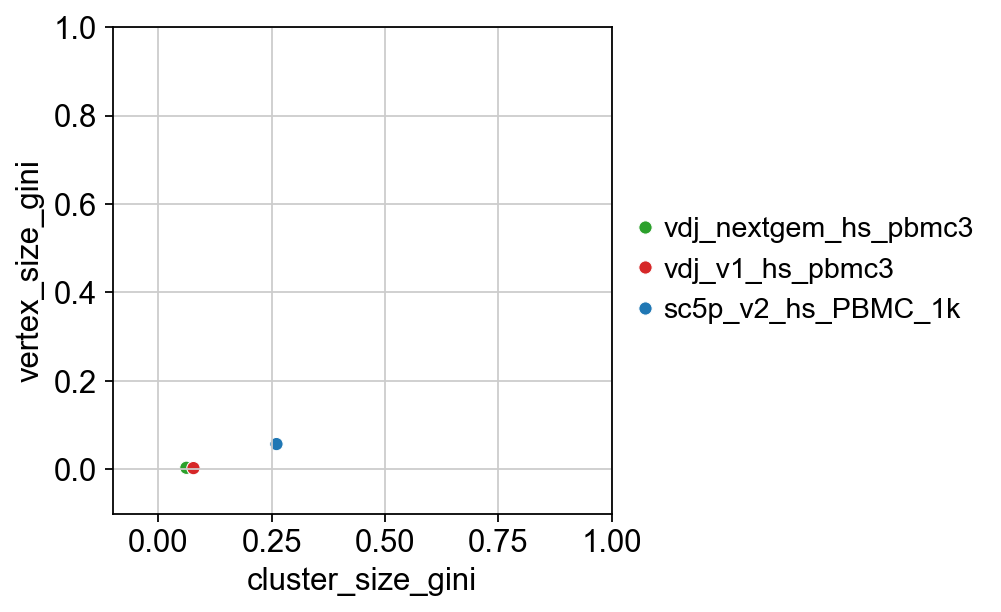

In [ ]:
# let's merge the two results dataframes for easier plotting
cluster_size = results["cluster_size_gini"][["sample_id", "mean"]]
vertex_size = results["vertex_size_gini"][["sample_id", "mean"]]
cluster_size.rename(columns={"mean": "cluster_size_gini"}, inplace=True)
vertex_size.rename(columns={"mean": "vertex_size_gini"}, inplace=True)
combined_results = pd.concat(
    [cluster_size.set_index("sample_id"), vertex_size.set_index("sample_id")],
    axis=1,
)
# set the colours
palette = dict(
    zip(adata.obs["sample_id"].cat.categories, adata.uns["sample_id_colors"])
)
p = sns.scatterplot(
    x="cluster_size_gini",
    y="vertex_size_gini",
    data=combined_results,
    hue=combined_results.index,
    palette=palette,
)
p.set(ylim=(-0.1, 1), xlim=(-0.1, 1))
plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False)
plt.show()

We can also plot the raw bootstrapped distributions for each sample to visualise the spread of the values.

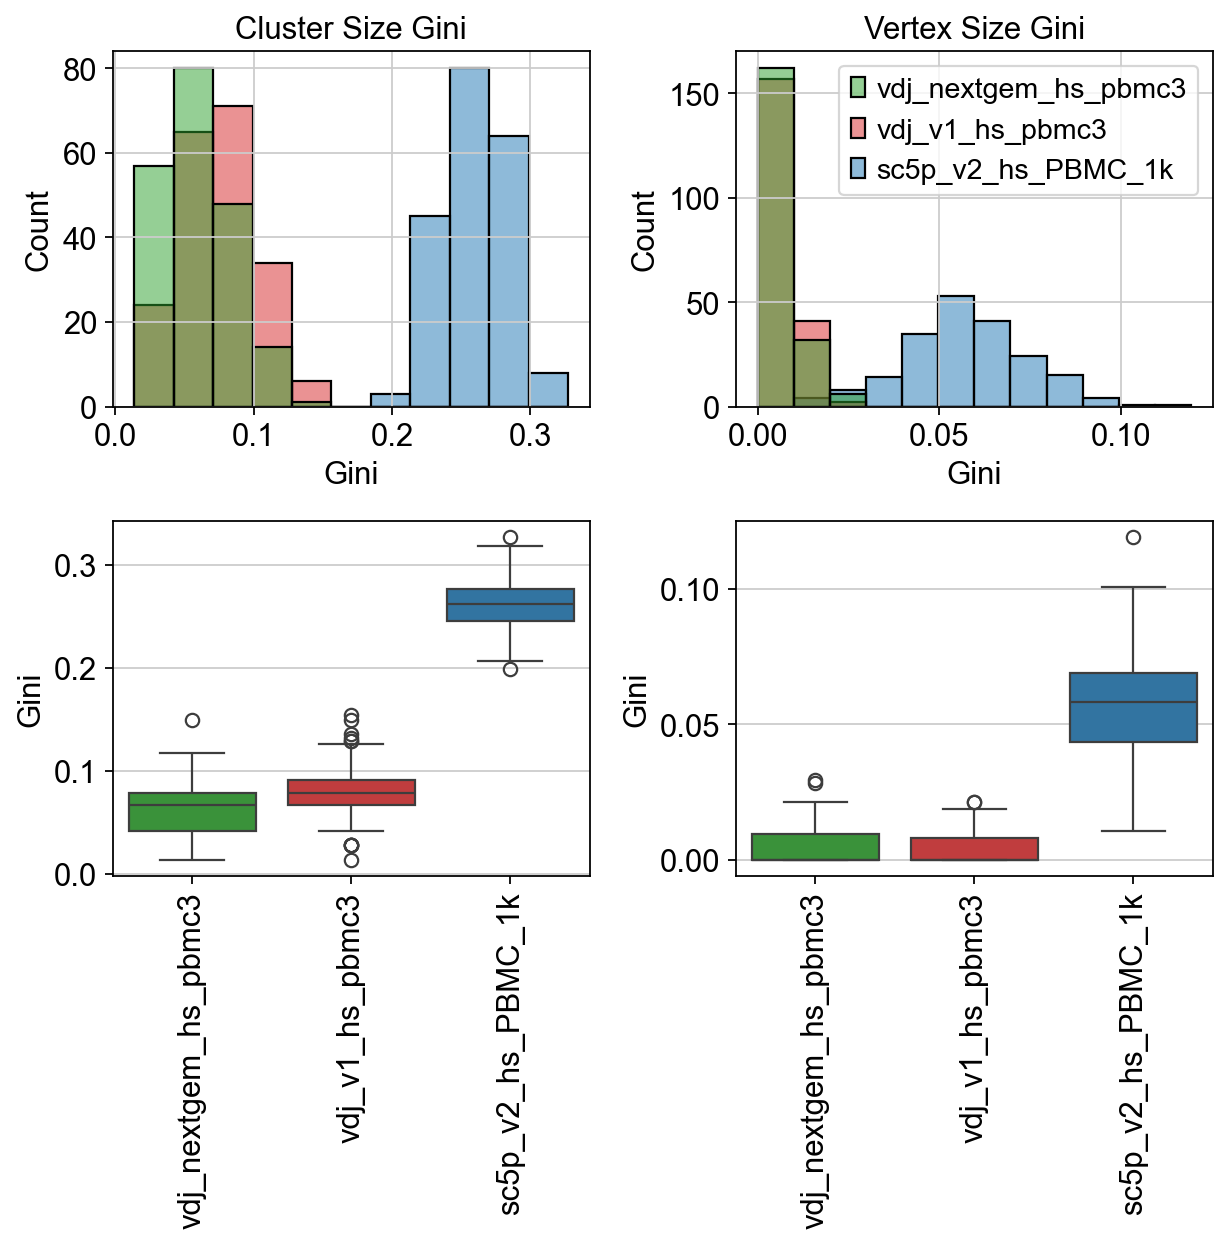

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))  # 1 row, 2 columns
sns.histplot(
    data=raw["cluster_size_gini"],
    palette=palette,
    ax=axes[0, 0],
)
sns.histplot(
    data=raw["vertex_size_gini"],
    palette=palette,
    ax=axes[0, 1],
)
sns.boxplot(
    data=raw["cluster_size_gini"],
    palette=palette,
    ax=axes[1, 0],
)
sns.boxplot(
    data=raw["vertex_size_gini"],
    palette=palette,
    ax=axes[1, 1],
)
axes[0, 0].set_title("Cluster Size Gini")
axes[0, 1].set_title("Vertex Size Gini")
axes[0, 0].legend_.remove()
axes[0, 0].set_xlabel("Gini")
axes[0, 1].set_xlabel("Gini")
axes[1, 0].set_ylabel("Gini")
axes[1, 1].set_ylabel("Gini")
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=90)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=90)
plt.tight_layout()
plt.show()

With these particular samples, because there is not many expanded clones in general, the gini indices are quite low when calculated within each sample. Let's try and simulate a really large number of cells.

In [ ]:
# now let's create a large sample using vdj_sample with probability weighting based on the clone size proportions so that larger clones are more likely to be sampled
ddl.tl.clone_size(vdj)
vdj_large = ddl.tl.vdj_sample(
    vdj_data=vdj,
    size=10000,
    p=vdj.metadata["clone_id_size_prop"],
    random_state=42,
)
vdj_large

Resampling to 10000 cells.
The AIRR data needs to undergo sanitization, apologies for any delays...


Dandelion class object with n_obs = 10000 and n_contigs = 21091
    data: 'sequence_id', 'sequence', 'rev_comp', 'productive', 'v_call', 'd_call', 'j_call', 'sequence_alignment', 'germline_alignment', 'junction', 'junction_aa', 'v_cigar', 'd_cigar', 'j_cigar', 'stop_codon', 'vj_in_frame', 'locus', 'c_call', 'junction_length', 'np1_length', 'np2_length', 'v_sequence_start', 'v_sequence_end', 'v_germline_start', 'v_germline_end', 'd_sequence_start', 'd_sequence_end', 'd_germline_start', 'd_germline_end', 'j_sequence_start', 'j_sequence_end', 'j_germline_start', 'j_germline_end', 'v_score', 'v_identity', 'v_support', 'd_score', 'd_identity', 'd_support', 'j_score', 'j_identity', 'j_support', 'fwr1', 'fwr2', 'fwr3', 'fwr4', 'cdr1', 'cdr2', 'cdr3', 'cell_id', 'consensus_count', 'umi_count', 'v_call_10x', 'd_call_10x', 'j_call_10x', 'junction_10x', 'junction_10x_aa', 'j_support_igblastn', 'j_score_igblastn', 'j_call_igblastn', 'j_call_blastn', 'j_identity_blastn', 'j_alignment_length_blastn'

Let's also go a bit further and introduce some mutations into the sequences to see how that affects the diversity measures.

In [ ]:
from Bio.Seq import Seq
import random

NUCLEOTIDES = ["A", "T", "C", "G"]
GAP_CHARS = {".", "-", "N"}  # You can extend this set if needed


def mutate_sequence(seq, mutation_rate=0.01):
    """Randomly mutate nucleotide sequence but skip gap characters."""
    seq_list = list(seq)

    for i, nt in enumerate(seq_list):
        # Skip gaps or unknown characters
        if nt.upper() not in NUCLEOTIDES:
            continue

        if random.random() < mutation_rate:
            # choose any nucleotide except the current one
            seq_list[i] = random.choice(
                [n for n in NUCLEOTIDES if n != nt.upper()]
            )

    return "".join(seq_list)


def translate_cleaned_nt(seq):
    """Remove gap characters and translate clean nucleotide sequence."""
    cleaned = "".join([nt for nt in seq if nt.upper() in NUCLEOTIDES])
    return str(Seq(cleaned).translate(to_stop=False))


def mutate_dataframe(df, nt_col="junction", mutation_rate=0.01):
    """Mutate nucleotide sequences in the DataFrame and update amino acids."""
    mutated_nt = []
    mutated_aa = []
    aa_col = nt_col + "_aa"
    for nt_seq in df[nt_col]:
        mutated_seq = mutate_sequence(nt_seq, mutation_rate)
        mutated_nt.append(mutated_seq)

        aa_seq = translate_cleaned_nt(mutated_seq)
        mutated_aa.append(aa_seq)

    df[nt_col] = mutated_nt
    df[aa_col] = mutated_aa
    return df

In [ ]:
vdj_large.data = mutate_dataframe(
    vdj_large.data, nt_col="sequence_alignment", mutation_rate=0.01
)

Generating network


Setting up data: 21091it [00:02, 7556.65it/s]


Calculating distance matrix  with distance_mode = 'clone'



100%|██████████| 1565/1565 [00:41<00:00, 37.89it/s] 


Distances calculated in 41.34 seconds


Linking edges : 100%|██████████| 1364/1364 [09:43<00:00,  2.34it/s]  


Generating network layout
To benefit from faster layout computation, please install graph-tool and use layout_method='sfdp': conda install -c conda-forge graph-tool
This message will only be shown once per session.
Computing network layout
Computing expanded network layout
 finished.
   Updated Dandelion object
:    'layout', graph layout
 (0:24:20)
Transferring network
 finished: updated `.obs` with `.metadata`
wrote `.obsm['X_vdj']` and `.obsm['X_vdj_expanded']`
wrote adata.obsp['connectivities'] & ['distances'] from graph[0]
stored RNA matrices under rna_* keys (stashed)
stored vdj matrices under 'vdj_connectivities' (+ '_expanded' and + '_full' if available)
added `.uns['clone_id']` clone-level mapping (0:00:00)


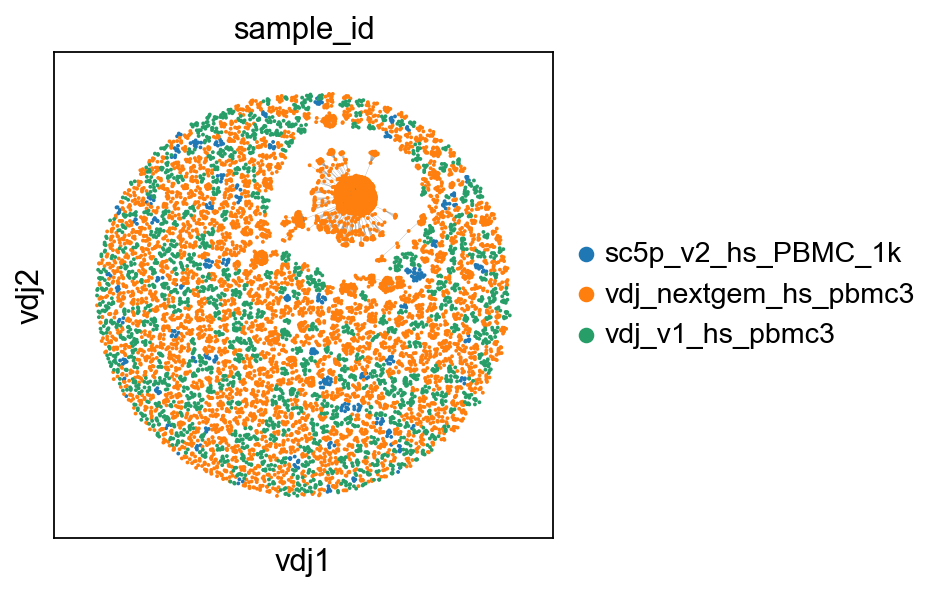

In [ ]:
# what does this dataset look like?
ddl.tl.generate_network(vdj_large, use_existing_graph=False)
adata_large = sc.AnnData(obs=vdj_large.metadata)
ddl.tl.transfer(adata_large, vdj_large)
ddl.pl.clone_network(adata_large, color=["sample_id"])

In [ ]:
results, raw = ddl.tl.clone_diversity(
    vdj_large,
    groupby="sample_id",
    method="gini",
    network_metric="clone_network",
    n_boot=200,
    n_cpus=8,
    verbose=True,
)
results

Calculating Gini indices


Bootstrapping... sc5p_v2_hs_PBMC_1k: 100%|██████████| 200/200 [00:52<00:00,  3.83it/s]


{'cluster_size_gini':               sample_id      mean       std  lower_95  upper_95
 0  vdj_nextgem_hs_pbmc3  0.354192  0.015923  0.324869  0.383595
 1       vdj_v1_hs_pbmc3  0.256731  0.010204  0.237930  0.277015
 2    sc5p_v2_hs_PBMC_1k  0.361340  0.020804  0.321802  0.401708,
 'vertex_size_gini':               sample_id      mean       std  lower_95  upper_95
 0  vdj_nextgem_hs_pbmc3  0.100757  0.009322  0.082923  0.118949
 1       vdj_v1_hs_pbmc3  0.181636  0.010700  0.160954  0.202228
 2    sc5p_v2_hs_PBMC_1k  0.327523  0.008888  0.310984  0.343879}

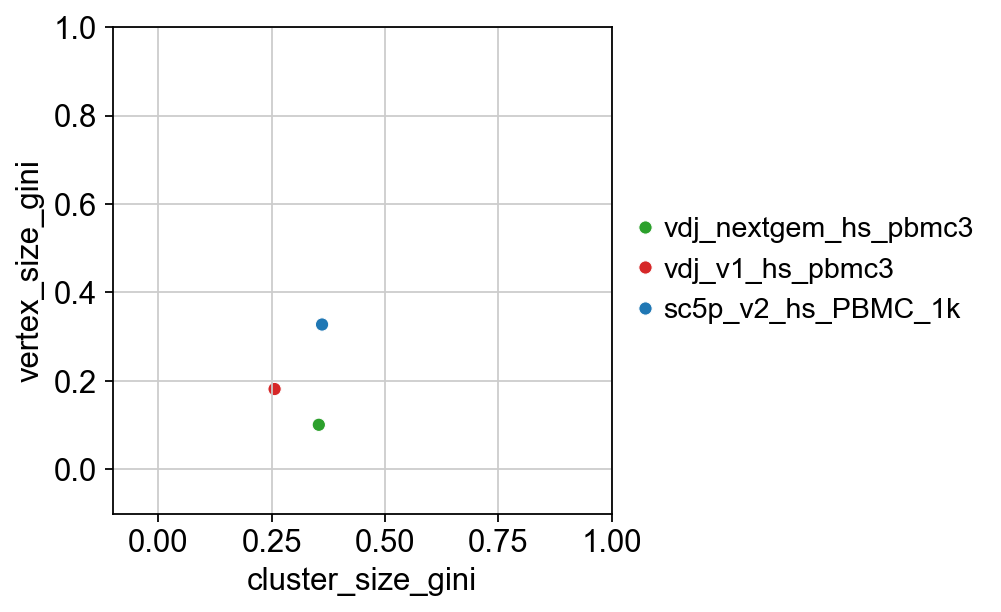

In [ ]:
# let's merge the two results dataframes for easier plotting
cluster_size = results["cluster_size_gini"][["sample_id", "mean"]]
vertex_size = results["vertex_size_gini"][["sample_id", "mean"]]
cluster_size.rename(columns={"mean": "cluster_size_gini"}, inplace=True)
vertex_size.rename(columns={"mean": "vertex_size_gini"}, inplace=True)
combined_results = pd.concat(
    [cluster_size.set_index("sample_id"), vertex_size.set_index("sample_id")],
    axis=1,
)
# set the colours
palette = dict(
    zip(adata.obs["sample_id"].cat.categories, adata.uns["sample_id_colors"])
)
p = sns.scatterplot(
    x="cluster_size_gini",
    y="vertex_size_gini",
    data=combined_results,
    hue=combined_results.index,
    palette=palette,
)
p.set(ylim=(-0.1, 1), xlim=(-0.1, 1))
plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False)
plt.show()

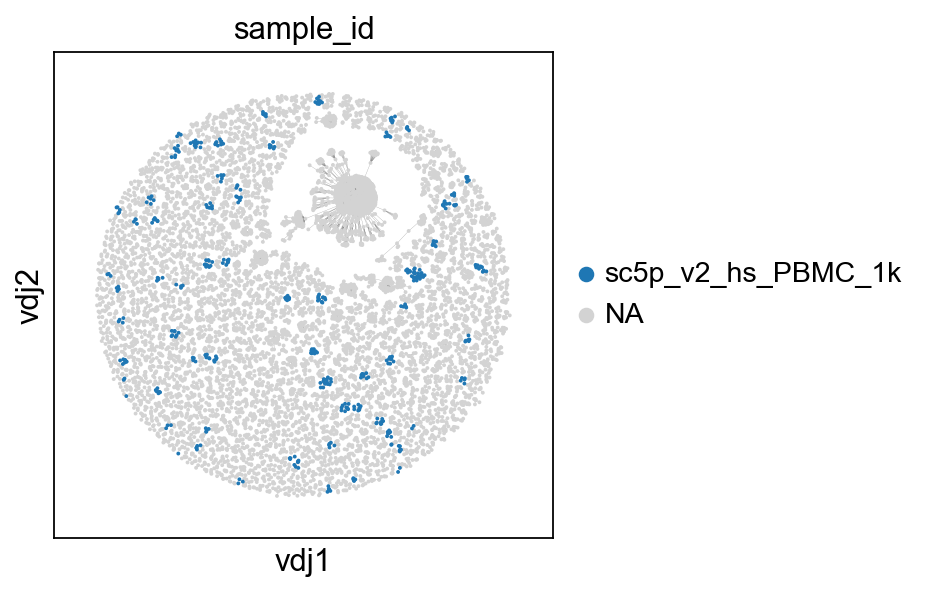

In [ ]:
ddl.pl.clone_network(
    adata_large, color=["sample_id"], groups=["sc5p_v2_hs_PBMC_1k"]
)

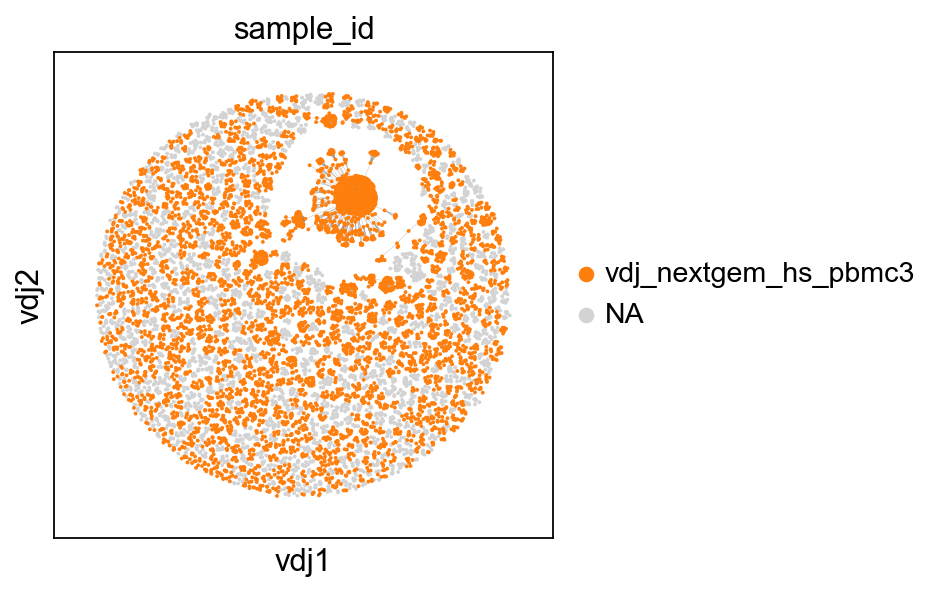

In [ ]:
ddl.pl.clone_network(
    adata_large, color=["sample_id"], groups=["vdj_nextgem_hs_pbmc3"]
)

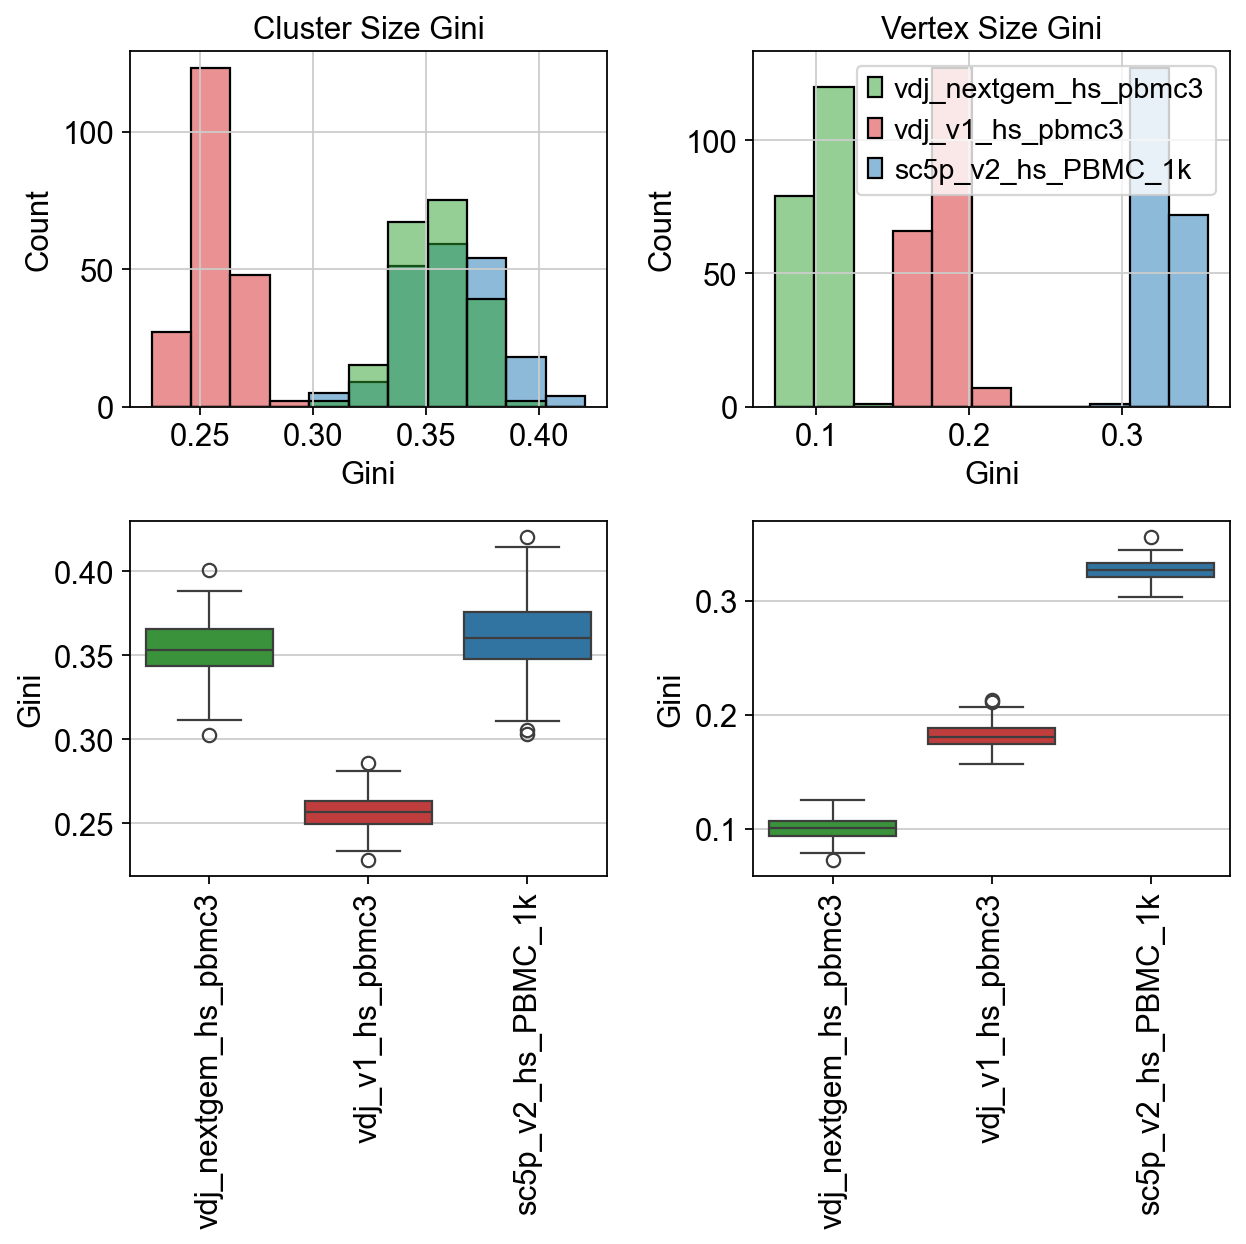

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))  # 1 row, 2 columns
sns.histplot(
    data=raw["cluster_size_gini"],
    palette=palette,
    ax=axes[0, 0],
)
sns.histplot(
    data=raw["vertex_size_gini"],
    palette=palette,
    ax=axes[0, 1],
)
sns.boxplot(
    data=raw["cluster_size_gini"],
    palette=palette,
    ax=axes[1, 0],
)
sns.boxplot(
    data=raw["vertex_size_gini"],
    palette=palette,
    ax=axes[1, 1],
)
axes[0, 0].set_title("Cluster Size Gini")
axes[0, 1].set_title("Vertex Size Gini")
axes[0, 0].legend_.remove()
axes[0, 0].set_xlabel("Gini")
axes[0, 1].set_xlabel("Gini")
axes[1, 0].set_ylabel("Gini")
axes[1, 1].set_ylabel("Gini")
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=90)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=90)
plt.tight_layout()
plt.show()

Now using `network_metric = "clone_centrality"`:

In [ ]:
results, raw = ddl.tl.clone_diversity(
    vdj_large,
    groupby="sample_id",
    method="gini",
    network_metric="clone_network",
    n_boot=200,
    n_cpus=8,
    verbose=True,
)
results

Calculating Gini indices


Bootstrapping... sc5p_v2_hs_PBMC_1k:  60%|██████    | 120/200 [00:41<00:28,  2.85it/s]

KeyboardInterrupt: 

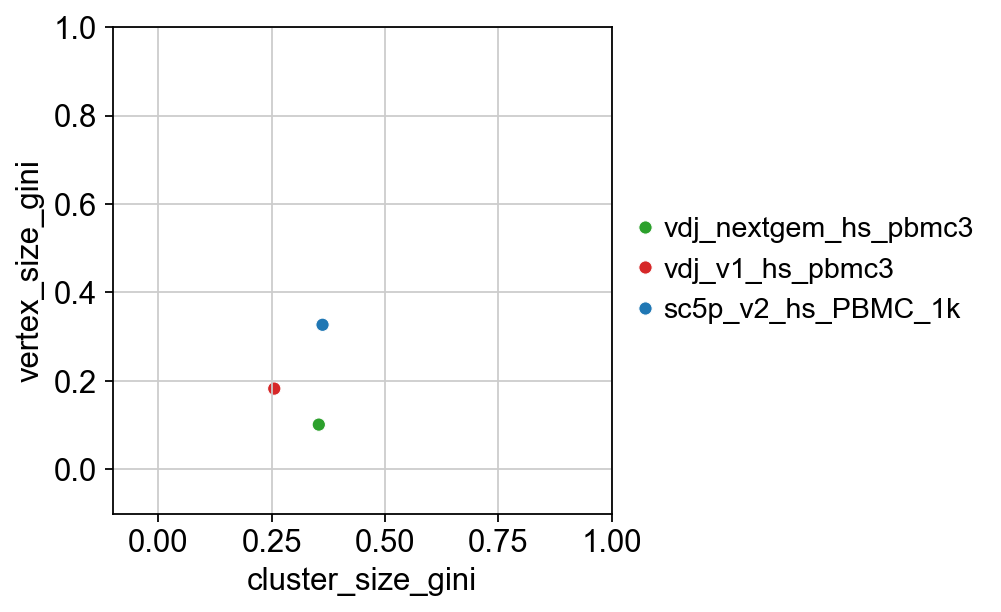

In [ ]:
# let's merge the two results dataframes for easier plotting
cluster_size = results["cluster_size_gini"][["sample_id", "mean"]]
vertex_size = results["vertex_size_gini"][["sample_id", "mean"]]
cluster_size.rename(columns={"mean": "cluster_size_gini"}, inplace=True)
vertex_size.rename(columns={"mean": "vertex_size_gini"}, inplace=True)
combined_results = pd.concat(
    [cluster_size.set_index("sample_id"), vertex_size.set_index("sample_id")],
    axis=1,
)
# set the colours
palette = dict(
    zip(adata.obs["sample_id"].cat.categories, adata.uns["sample_id_colors"])
)
p = sns.scatterplot(
    x="cluster_size_gini",
    y="vertex_size_gini",
    data=combined_results,
    hue=combined_results.index,
    palette=palette,
)
p.set(ylim=(-0.1, 1), xlim=(-0.1, 1))
plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False)
plt.show()

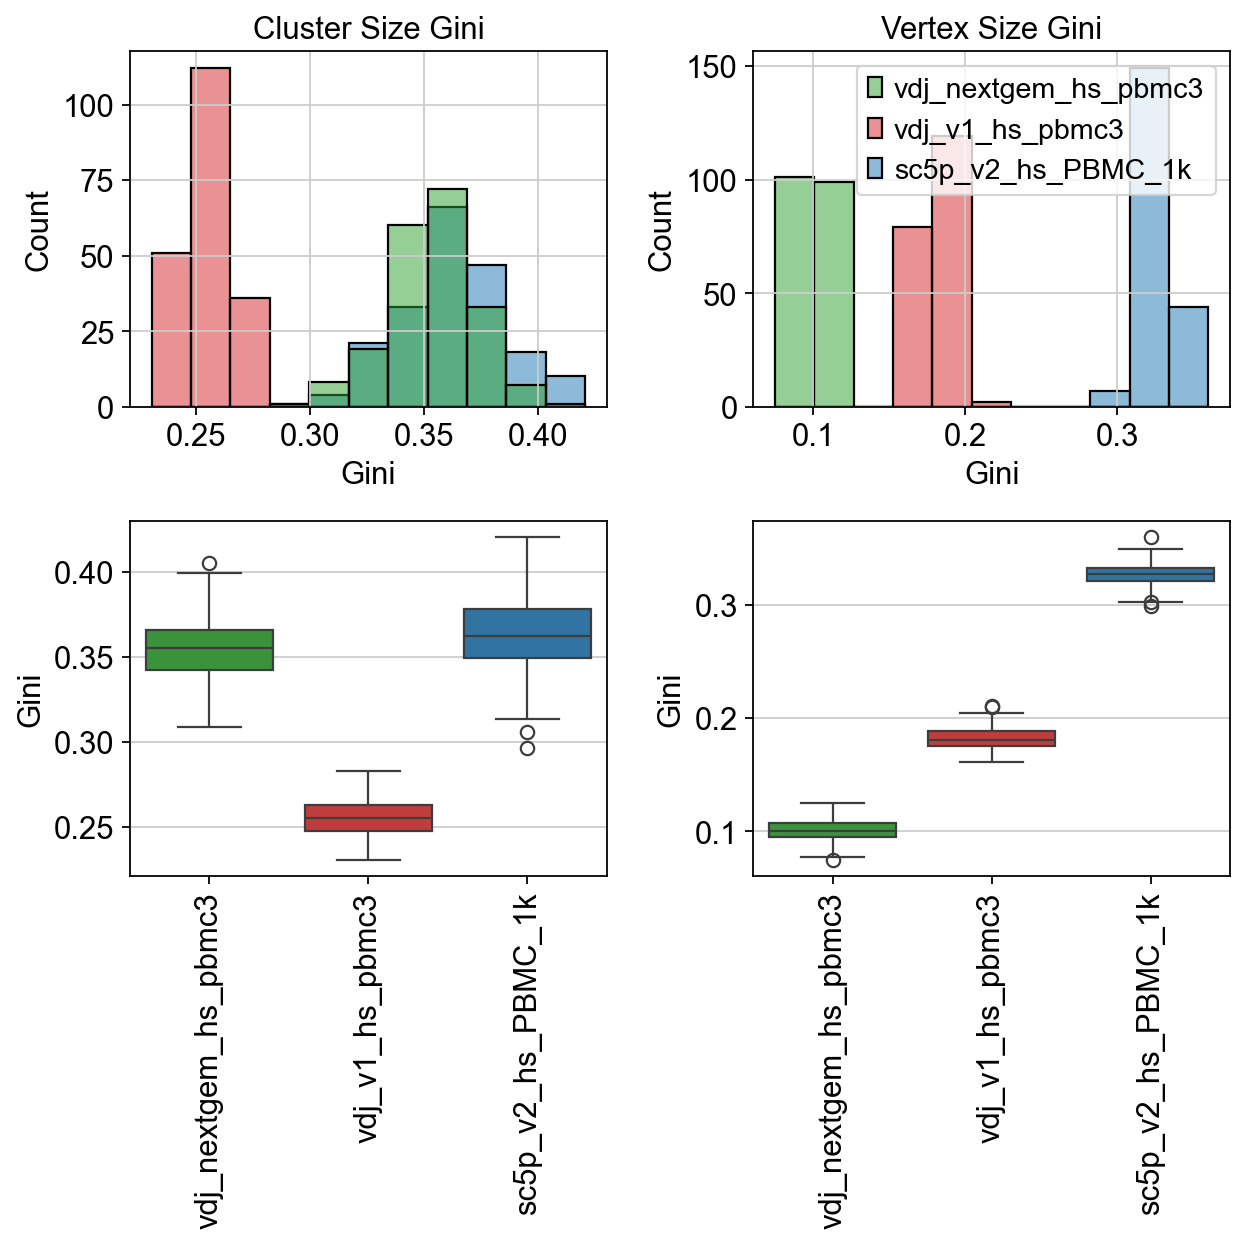

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))  # 1 row, 2 columns
sns.histplot(
    data=raw["cluster_size_gini"],
    palette=palette,
    ax=axes[0, 0],
)
sns.histplot(
    data=raw["vertex_size_gini"],
    palette=palette,
    ax=axes[0, 1],
)
sns.boxplot(
    data=raw["cluster_size_gini"],
    palette=palette,
    ax=axes[1, 0],
)
sns.boxplot(
    data=raw["vertex_size_gini"],
    palette=palette,
    ax=axes[1, 1],
)
axes[0, 0].set_title("Cluster Size Gini")
axes[0, 1].set_title("Vertex Size Gini")
axes[0, 0].legend_.remove()
axes[0, 0].set_xlabel("Gini")
axes[0, 1].set_xlabel("Gini")
axes[1, 0].set_ylabel("Gini")
axes[1, 1].set_ylabel("Gini")
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=90)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=90)
plt.tight_layout()
plt.show()

Finally, let's try the other diversity methods. `chao1` is an estimator based on abundance.

In [ ]:
results, raw = ddl.tl.clone_diversity(
    vdj_large,
    groupby="sample_id",
    method="chao1",
    n_boot=200,
    n_cpus=8,
    verbose=True,
)
results

Bootstrapping… sc5p_v2_hs_PBMC_1k: 100%|██████████| 200/200 [00:00<00:00, 3316.35it/s]


{'chao1':               sample_id        mean        std    lower_95    upper_95
 0  vdj_nextgem_hs_pbmc3  704.324325  90.406975  558.046276  891.389068
 1       vdj_v1_hs_pbmc3  445.304196  35.564217  378.653433  525.513290
 2    sc5p_v2_hs_PBMC_1k   69.615410   2.484946   65.662500   74.660000}

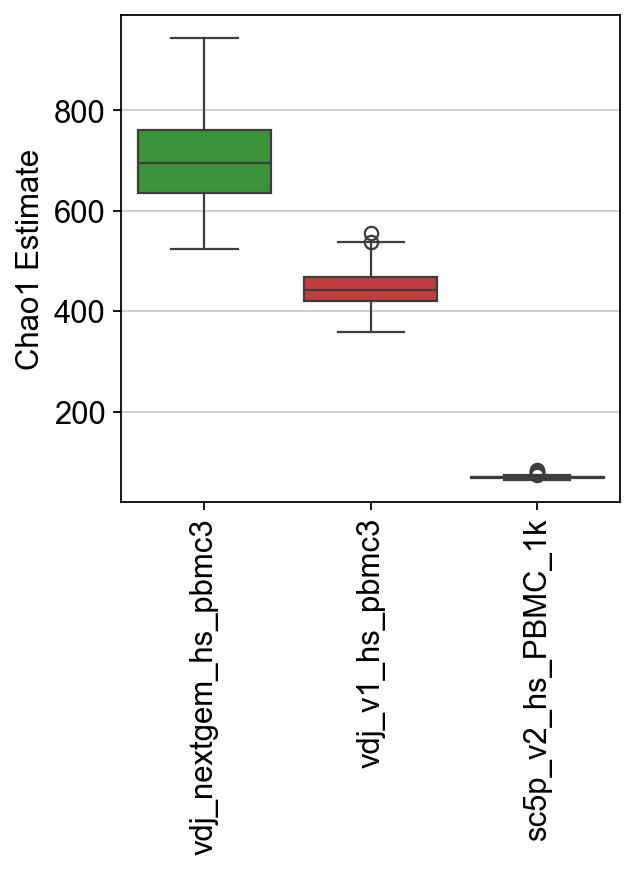

In [ ]:
ax = sns.boxplot(
    data=raw["chao1"],
    palette=palette,
)
ax.set_ylabel("Chao1 Estimate")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.show()

For Shannon Entropy, we can calculate a normalized (inspired by [scirpy's function](https://icbi-lab.github.io/scirpy/generated/scirpy.tl.alpha_diversity.html?highlight=diversity#scirpy.tl.alpha_diversity)) and non-normalized value.

In [ ]:
results, raw = ddl.tl.clone_diversity(
    vdj_large,
    groupby="sample_id",
    method="shannon",
    n_boot=200,
    n_cpus=8,
    verbose=True,
)
results

Bootstrapping… sc5p_v2_hs_PBMC_1k: 100%|██████████| 200/200 [00:00<00:00, 2075.36it/s]


{'shannon':               sample_id      mean       std  lower_95  upper_95
 0  vdj_nextgem_hs_pbmc3  0.873877  0.014568  0.843126  0.900330
 1       vdj_v1_hs_pbmc3  0.977783  0.001767  0.974501  0.981687
 2    sc5p_v2_hs_PBMC_1k  0.948591  0.006092  0.937212  0.961199}

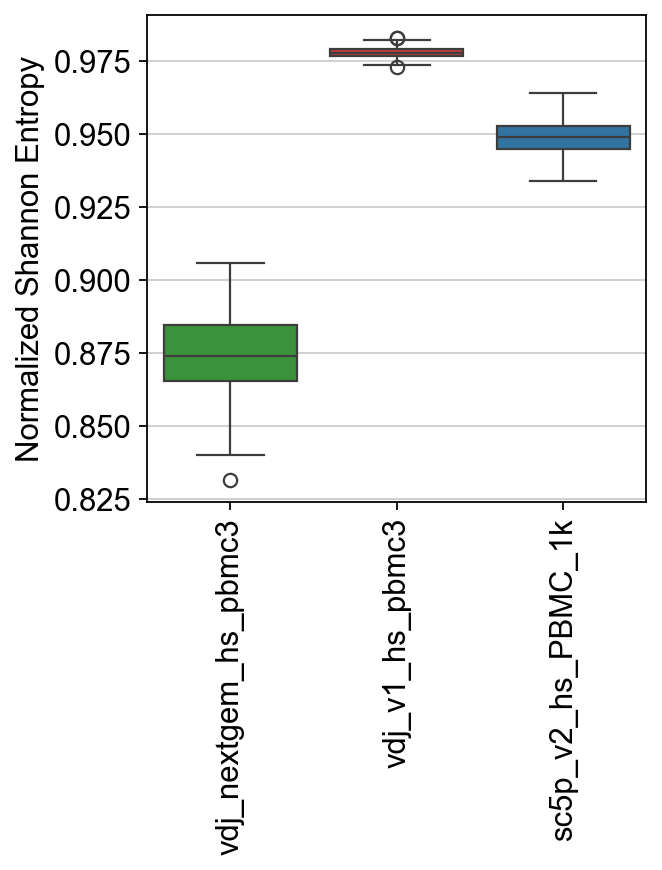

In [ ]:
ax = sns.boxplot(
    data=raw["shannon"],
    palette=palette,
)
ax.set_ylabel("Normalized Shannon Entropy")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.show()

In [ ]:
results, raw = ddl.tl.clone_diversity(
    vdj_large,
    groupby="sample_id",
    method="shannon",
    n_boot=200,
    n_cpus=8,
    verbose=True,
    normalize=False,
)
results

Bootstrapping… sc5p_v2_hs_PBMC_1k: 100%|██████████| 200/200 [00:00<00:00, 3097.75it/s]


{'shannon':               sample_id      mean       std  lower_95  upper_95
 0  vdj_nextgem_hs_pbmc3  7.046284  0.139161  6.787147  7.289700
 1       vdj_v1_hs_pbmc3  7.897568  0.044217  7.804948  7.973967
 2    sc5p_v2_hs_PBMC_1k  5.778370  0.044346  5.694848  5.853554}

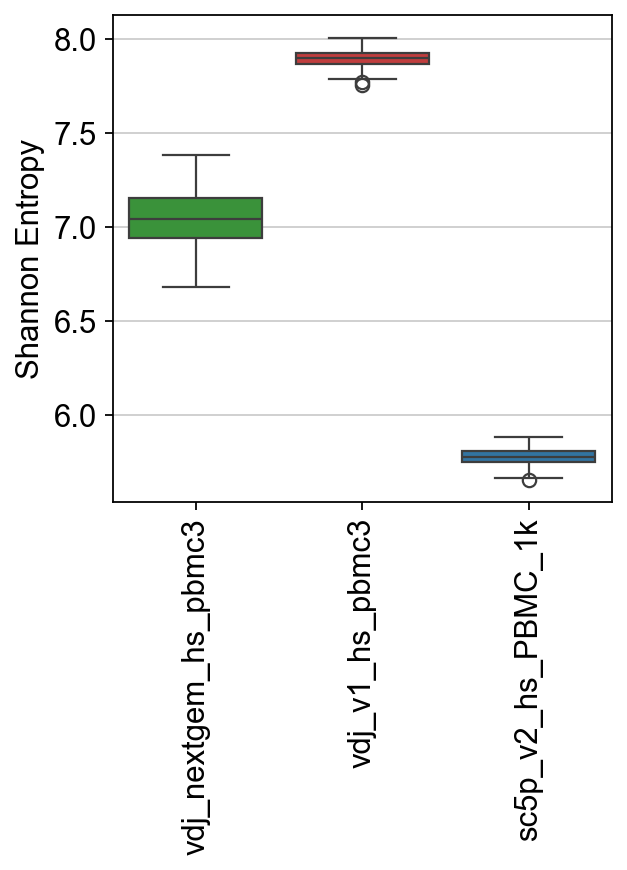

In [ ]:
ax = sns.boxplot(
    data=raw["shannon"],
    palette=palette,
)
ax.set_ylabel("Shannon Entropy")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.show()

There's also a `gini` method that doesn't require network construction, which should be faster to compute.

In [ ]:
results, raw = ddl.tl.clone_diversity(
    vdj_large,
    groupby="sample_id",
    method="gini",
    use_network=False,
    n_boot=200,
    n_cpus=8,
    verbose=True,
)
results

Bootstrapping… sc5p_v2_hs_PBMC_1k: 100%|██████████| 200/200 [00:00<00:00, 1364.76it/s]


{'gini':               sample_id      mean       std  lower_95  upper_95
 0  vdj_nextgem_hs_pbmc3  0.349671  0.017387  0.316002  0.380284
 1       vdj_v1_hs_pbmc3  0.254826  0.009780  0.235929  0.274586
 2    sc5p_v2_hs_PBMC_1k  0.347472  0.021415  0.307608  0.384987}

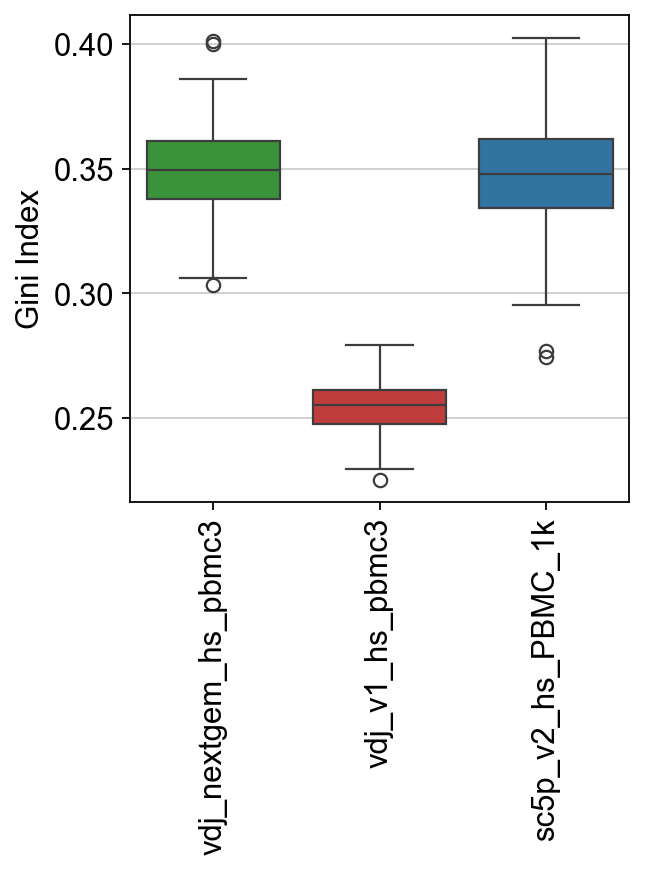

In [ ]:
ax = sns.boxplot(
    data=raw["gini"],
    palette=palette,
)
ax.set_ylabel("Gini Index")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.show()

That sums it up for now! Let me know if you have any ideas at [z.tuong@uq.edu.au] and I can try and see if i can implement it or we can work something out to collaborate on!